In [1]:
import numpy as np
import math

In [2]:
import matplotlib.pyplot as plt

In [3]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination
from pymoo.optimize import minimize

In [29]:
class ray_tai_seow(ElementwiseProblem):
    """
    Python translation of MATLAB function RayTaiSeow problem

    RayTaiSeow.m
    Ray, Tai and Seow (2001) Water Resource Planning problem.
    In a drainage system 3 main decision variables have been identified for
    decision making. This leads to 5 objective functions (non-linear), 
    coupled with 7 constraints due to resource limitations and water quality
    requirements.

    Parameters
    ----------
    x : array-like of length 3
        Decision variables:
        0.01 <= x[0] <= 0.45
        0.01 <= x[1] <= 0.10
        0.01 <= x[2] <= 0.10

    Returns
    -------
    f : ndarray (5,)
        Objective function values
    g : ndarray (7,)
        Constraint violations (<= 0 is feasible)

    References:
    The story goes like this, found this problem on [1] where is referenced to [2].
    However in [2] it is explained little and refers to [3] and [4], but in
    neither of them is extensively explained the choice of surfaces, although 
    the problem is presented in all as it is written here. 
    Seems that the problem was studied in a PhD thesis at Purdue 
    by Dendrou, S. in 1978, but only found online the report presented in [5].
    
    In [5], the whole model is discussed but not the simplifications concerning 
    creating the objective functions and more important the constraints as surfaces.
    As a matter of fact this problem can be seen as a meta-model for
    water resources planning.
    
    [1] Deb, K. (2001) Multi-Objective Optimization using Evolutionary Algorithms.
        Editorial Wiley & Sons. pp 518. ISBN: 978-0-471-87339-6
    [2] Ray, T., Tai, K., and Seow, K-C. (2001) Multiobjective Design Optimization by and Evolutionary Algorithm
        Engineering Optimization, 33(4), 399-424. DOI:10.1080/03052150108940926
    [3] Cheng, F.Y. and Li, X.S. (1999) Generalized method for multiobjective engineering optimization.
        Engineering Optimization, 31(5), 641-661.
    [4] Musselman, K. and Talavage, J. (1980). A trade-off cut approach to multiple objective 
        optimization. Operations Research, 28(6), 1424-1435.
    [5] Dendrou, S., Delleur, J.W., and Talavage, J.J. (1978) "Urban Growth In Water Resources Planning, 
        Multilevel Approach To Urban Water Resources Systems Analysis -- Application To Medium Size Communities" . 
        IWRRC Technical Reports. Paper 100. http://docs.lib.purdue.edu/watertech/100
     
    Developed by : Mario Castro Gama, ir. MSc. PhD
                   sr Specialist Infrastructure VITENS N.V.
    Last update  : 2015-05-14,
                   2026-02-01, translated into python 
    """

    def __init__(self):
        super().__init__(n_var=3,
                     n_obj=5,
                     n_ieq_constr=7,
                     xl=np.array([0.01, 0.01, 0.01]),
                     xu=np.array([0.45, 0.10, 0.10]))
    
    
    def _evaluate(self, x, out, *args, **kwargs):
        # x[0] Storage
        # x[1] Treatment facility
        # x[2] Overflow 
        x = np.asarray(x, dtype=float)
    
        f = np.zeros(5)
        g = np.zeros(7)
    
        # ---- Constraints ----
        # c[0] : Average number of floods per year
        g[0] = 0.00139 / (x[0] * x[1]) + 4.940 * x[2] - 0.0800 - 1.0
        
        # c[1] : Probability of excedding a flood depth of 0.,01 inches
        g[1] = 0.000306 / (x[0] * x[1]) + 1.082 * x[2] - 0.0986 - 1.0
    
        # c[2] : Average number of pounds per year of suspended sediments
        g[2] = 12.307 / (x[0] * x[1]) + 49408.240 * x[2] + 4051.0200 - 50000.0
    
        # c[3] : Average number of pounds per year of Transported sediments
        g[3] = 2.098 / (x[0] * x[1]) + 8046.333 * x[2] - 696.7100 - 16000.0
    
        # c[4] Average number of pounds per year of BOB
        g[4] = 2.138 / (x[0] * x[1]) + 7883.390 * x[2] - 705.0400 - 10000.0
    
        # c[5] : Average number of pounds per year of N
        g[5] = 0.417 / (x[0] * x[1]) + 1721.260 * x[2] - 136.5400 - 2000.0
        
        # c[6] : Average number of pounds per year of PO_4
        g[6] = 0.164 / (x[0] * x[1]) + 631.130 * x[2] - 54.4800 - 550.0
    
        FlagConstraint = 0
        if FlagConstraint == 1:
            g[:] = 0.0
            
        # ---- Objective functions ----
        # f[0] : Drainage network cost (10^3 USD)
        f[0] = 106780.37 * (x[1] + x[2]) + 61704.67
        f[0] /= 1e3 #8e4
    
        # f[1] : Storage area cost (10^3 USD)
        f[1] = 3000.0 * x[0]
        f[1] /= 1e3 #1500.0
    
        # f[2] : Treatment plant cost (10^6 USD)
        f[2] = 305700.0 * 2289.0 * x[1] / (0.05 * 2289.0) ** 0.65
        f[2] /= 1e6 #3e6
    
        # Expected flood damage cost on Infrastructure (10^6 USD)
        f[3] = 250.0 * 2289.0 * math.exp(-39.75 * x[1] + 9.90 * x[2] + 2.74)
        f[3] /= 1e6
    
        # Expected economic loss due to flooding (10^3 USD)
        f[4] = 25.0 * (1.39 / (x[0] * x[1]) + 4940.0 * x[2] - 80.0)
        f[4] /= 1e3

        out['F'] = f
        out['G'] = g


In [27]:
# explicitly use the problem
problem = ray_tai_seow()

In [5]:
algorithm = NSGA2(
    pop_size     = 500,
    n_offsprings = 500,
    sampling     = FloatRandomSampling(),
    crossover    = SBX(prob=0.9, eta=15),
    mutation     = PM(eta=20),
    eliminate_duplicates = True
)

In [6]:
termination = get_termination('n_gen', 1000)

In [7]:
res = minimize(problem,
               algorithm,
               termination,
               seed=1,
               save_history=True,
               verbose=False)

In [8]:
print('TOC optimization : '+str(round(res.exec_time,2))+' seconds')

TOC optimization : 197.12 seconds


In [9]:
X, F, G = res.opt.get('X', 'F', 'G')
print(X.shape, F.shape, G.shape)

(500, 3) (500, 5) (500, 7)


In [10]:
print(len(res.history))

1000


In [11]:
# Get all function evaluations
n_evals = []
hist_F = []
hist_X = []
hist_G = []
for algo in res.history:
    n_evals.append(algo.evaluator.n_eval)
    opt = algo.opt
    feas = np.where(opt.get('feasible'))[0]
    hist_F.append(opt.get('F')[feas])
    hist_X.append(opt.get('X')[feas])
    hist_G.append(opt.get('G')[feas])


In [12]:
len(hist_F[0]), len(hist_G[0]), len(hist_X[0])

(147, 147, 147)

In [13]:
len(hist_F[-1]), len(hist_G[-1]), len(hist_X[-1])

(500, 500, 500)

In [14]:
# extract all values from the lists of PYMOO to operate with them
def list_array2array(HH):
    for i,v in enumerate(HH):
        if i == 0:
            XX = v
        else:
            XX = np.concatenate((XX,v),axis=0)
    return XX

In [15]:
OF = list_array2array(hist_F)
CO = list_array2array(hist_G)
DV = list_array2array(hist_X)

In [16]:
OF.shape, CO.shape, DV.shape

((499133, 5), (499133, 7), (499133, 3))

In [24]:
OFnames = {
    'F_1' : 'Drainage network cost \n $[10^3 USD]$',
    'F_2' : 'Storage area cost \n $[10^3 USD]$',
    'F_3' : 'Treatment plant cost \n $[10^6 USD]$',
    'F_4' : 'Expected flood damage cost on Infrastructure \n $[10^6 USD]$',
    'F_5' : 'Expected economic loss due to flooding \n $[10^3 USD]$'}

In [47]:
# save to file
np.savetxt('WATER_500k.txt', np.concatenate((OF,CO,DV),axis=1),
           fmt='%.18e', delimiter=',', newline='\n', 
           header='F_1,F_2,F_3,F_4,F_5,G_1,G_2,G_3,G_4,G_5,G_6,G_7,X_1,X_2,X_3')

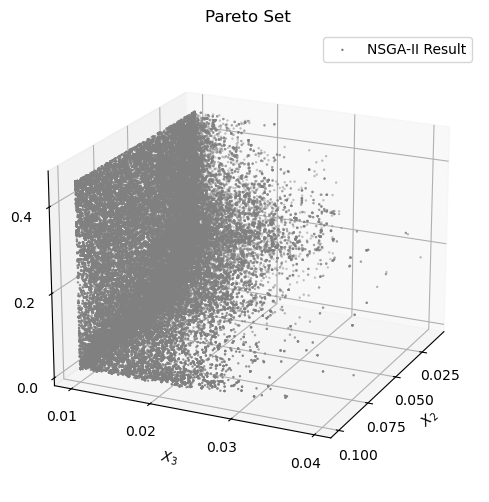

In [30]:
# plot the results
idx_ini = 400000
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.scatter(DV[idx_ini:,1],
           DV[idx_ini:,2],
           DV[idx_ini:,0],
           c='gray',
           s=3,
           edgecolors='none',
           label = 'NSGA-II Result')
ax.set_title('Pareto Set')
ax.set_xlabel('$X_2$')
ax.set_ylabel('$X_3$')
ax.set_zlabel('$X_1$')
ax.view_init(elev=20.0, azim=25.0, roll=0.0)
ax.locator_params(nbins=4)
ax.legend()
plt.show()

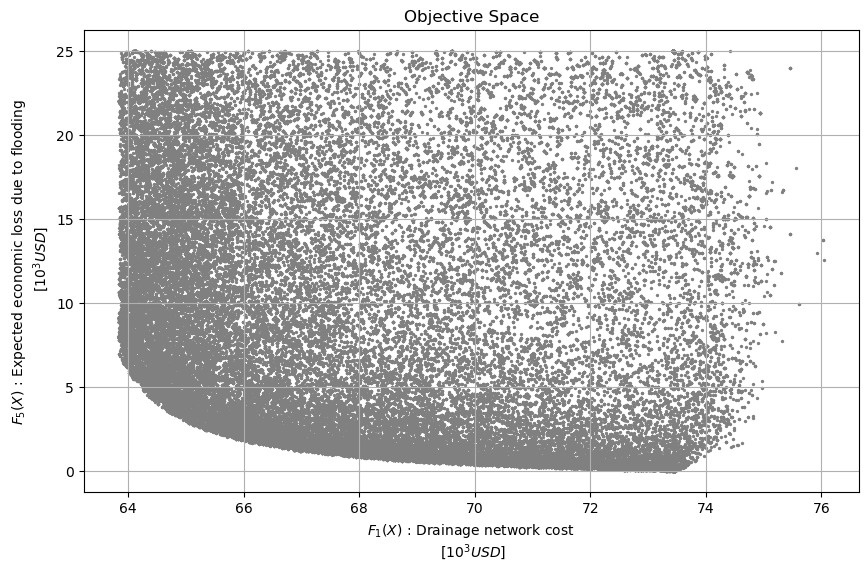

In [25]:
# plot results Objective Space
ivar = 1
jvar = 5
idx_ini = 400000
plt.figure(figsize=(10, 6))
plt.scatter(OF[idx_ini:, ivar-1], OF[idx_ini:, jvar-1], s=2, facecolors='gray', edgecolors='gray')
plt.title("Objective Space")
plt.xlabel(r'$F_'+str(ivar)+'(X)$ : '+OFnames['F_'+str(ivar)]+'')
plt.ylabel(r'$F_'+str(jvar)+'(X)$ : '+OFnames['F_'+str(jvar)]+'')
plt.grid(which='both')
plt.show()

In [33]:
import itertools
import math
from scipy.stats import pearsonr

In [31]:
def tradeoff_index(XX, ncolor=8, out_clr=None, OFnames=None):
    """
    Python translation of MATLAB function tradeoff_index

    Parameters
    ----------
    XX : ndarray (nsols, nobj)
        Objective values
    ncolor : int
        Number of colors
    out_clr : ndarray or None
        Color palette
    OFnames : list of str or None
        Objective names

    Returns
    -------
    hh : matplotlib.figure.Figure
        Figure handle
    lambdas : ndarray
        Lambda matrices (nrows, nrows, ntradeoffs)
    to_names : list
        Trade-off names
    """

    XX = np.asarray(XX, dtype=float)
    nsols, nobj = XX.shape

    # Objective names
    if OFnames is None or len(OFnames) == 0:
        OFnames = [f"obj{i+1}" for i in range(nobj)]

    # Plot options
    #sel_fontname = "Times"
    sel_fontsize = 6
    sel_fontweight = "normal"
    ndecimals = 3
    strformat = f"%.{ndecimals}f"

    # Rescale objectives to [0,1]
    XX2 = (XX - XX.min(axis=0)) / (XX.max(axis=0) - XX.min(axis=0))

    ntradeoffs = math.comb(nobj, 2)
    nrows = int(np.ceil(np.sqrt(nsols)))
    print(nrows)
    
    lambdas = np.zeros((nrows, nrows, ntradeoffs))

    # Correlations
    rhoes = np.zeros((nobj, nobj))
    pvals = np.zeros((nobj, nobj))
    for i in range(nobj):
        for j in range(nobj):
            rhoes[i, j], pvals[i, j] = pearsonr(XX2[:, i], XX2[:, j])

    # ---- Tradeoff Index estimation ----
    to_names = []
    ito = 0

    for of1 in range(nobj - 1):
        for of2 in range(of1 + 1, nobj):
            ito += 1
            L = np.zeros(nrows * nrows)

            for si in range(nsols):
                beta = np.zeros(nsols)
                for sj in range(nsols):
                    if si != sj:
                        xp = (XX2[si, of1] - XX2[sj, of1]) * \
                             (XX2[si, of2] - XX2[sj, of2])
                        if xp < 0:
                            beta[sj] = 1.0
                L[si] = np.sum(beta) / (nsols - 1)

            lambdas[:, :, ito - 1] = L.reshape((nrows, nrows)).T

            percentage = (np.sum(L) / nsols) * 100
            label = [
                #f"{OFnames[of1]} -> {OFnames[of2]}",
                f"$\\lambda$:{percentage:3.1f}",
                f"$r = {rhoes[of1, of2]:1.3f}$"
            ]
            
            to_names.append(label)

    # ---- Plotting ----
    hh = plt.figure(figsize=(10.1, 9.1), facecolor="white")
    ax = plt.gca()

    xfalse = (np.arange(nrows) + 0.5) / nrows
    text_size = 18 - nobj
    ito = 0
    
    # Colormap
    if out_clr is None:
        out_clr = create_colors(ncolor)

    cmap = plt.colormaps['RdBu_r']#, ncolor)
    
    #plt.clim(0, 1)
    
    for of1 in range(nobj - 1):
        for of2 in range(of1 + 1, nobj):
            ito += 1
            xp = (of2 - 1) + xfalse
            yp = (nobj - (of1 + 2)) + xfalse
            

            X, Y = np.meshgrid(xp, yp)
            Z = lambdas[:, :, ito - 1]
            ax.pcolormesh(X, Y, Z, shading="nearest", cmap=cmap)

            ax.text(
                np.mean(xp), np.mean(yp),
                "\n".join(to_names[ito - 1]),
                ha = "center", 
                va = "center",
                fontsize   = text_size, #fontname=sel_fontname,
                fontweight = sel_fontweight,
                bbox       = dict(facecolor="white", edgecolor="black")
            )
            #ax.cmap(cmap)
    # Frame
    ax.plot([0, nobj-1, nobj-1, 0, 0],
            [0, 0, nobj-1, nobj-1, 0],
            "k-", linewidth = 0.5)

    plt.grid(which='both')
    #ax.set_xlim(0, nobj - 1)
    #ax.set_ylim(0, nobj - 1)
    ax.set_xticks(np.arange(0,nobj-1)+0.5)#[0, nobj-1])
    ax.set_yticks(np.arange(0,nobj-1)+0.5)#[0, nobj-1])
    ax.set_xticklabels(OFnames[1:])#['', ''])
    ax.set_yticklabels(OFnames[::-1][1:])#['', ''])
    ax.set_aspect("equal")

    ax.set_title(
        "Trade-off Index $\\lambda$ [%]", #fontname=sel_fontname,
        fontsize=sel_fontsize + 6,
        fontweight="bold"
    )

    #ax.colorbar()

    #cbar = plt.colorbar(
    #    ticks=np.linspace(0, 1, ncolor + 1),
    #    fraction=0.046, pad=0.04
    #)
    #cbar.ax.set_title("$\\lambda$", fontsize=sel_fontsize + 4)

    return hh, lambdas, to_names

In [32]:
def create_colors(ncolor):
    return plt.cm.RdBu_r(np.linspace(0, 1, ncolor))

In [41]:
OF.shape[0]-50*50

496633

50


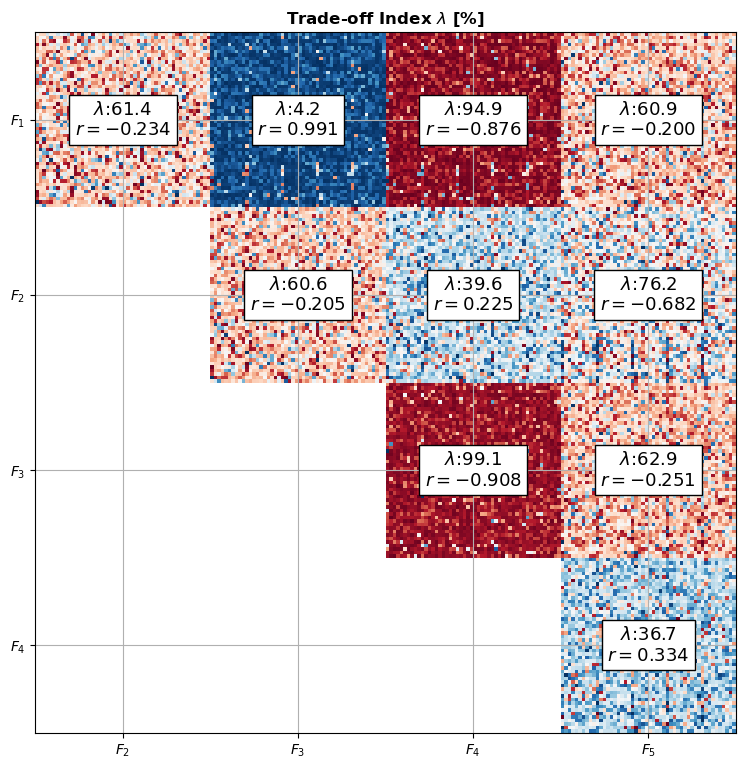

In [43]:
fig, lambdas, names = tradeoff_index(
    OF[496633:,:],
    ncolor  = 8,
    OFnames = ['$F_1$', '$F_2$', '$F_3$', '$F_4$','$F_5$'], #
)

plt.show()